In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import KroghInterpolator, CubicHermiteSpline
from scipy.integrate import simpson

In [2]:
def resolve_edo_hermite(n_subintervalos):
    t = np.linspace(0, 1, 10000)
    y = np.exp(t)

    resultados_erro = []

    for n in n_subintervalos:
        nos_t = np.linspace(0, 1, n + 1)
        nos_y = np.exp(nos_t)
        nos_y_derivada = np.exp(nos_t)

        spline = CubicHermiteSpline(nos_t, nos_y, nos_y_derivada)
        y_spline = spline(t)
        erro_spline = simpson(y=np.abs(y_spline - y), x=t)

        xi = np.repeat(nos_t, 2)
        yi = np.zeros_like(xi)
        yi[0::2] = nos_y
        yi[1::2] = nos_y_derivada

        krogh = KroghInterpolator(xi, yi)
        y_global = krogh(t)

        erro_global = simpson(y=np.abs(y_global - y), x=t)

        resultados_erro.append((n, erro_spline, erro_global))

        plt.figure(figsize=(10, 5))
        plt.plot(t, y, "k-", label="Solução Exata ($e^t$)", linewidth=2)
        plt.plot(t, y_spline, "b--", label="Spline Cúbica (Por Partes)")

        plt.plot(t, y_global, "r:", label=f"Hermite Global (Grau {2*n+1})")
        plt.ylim(0.8, np.exp(1) + 0.2)

        plt.scatter(
            nos_t,
            nos_y,
            color="black",
            zorder=5,
            label="Nós ($n$ subintervalos)",
        )
        plt.title(f"Interpolação de Hermite para $n={n}$")
        plt.xlabel("t")
        plt.ylabel("y(t)")
        plt.legend()
        plt.grid(True)
        plt.show()

    print(f"{'n':<6}, {'Erro Spline Cúbica':<25}, {'Erro Hermite Global':<25}")
    for n, e_spline, e_global in resultados_erro:
        e_g_str = f"{e_global:.5e}"
        print(f"{n:<6} | {e_spline:<25.5e} | {e_g_str:<25}")

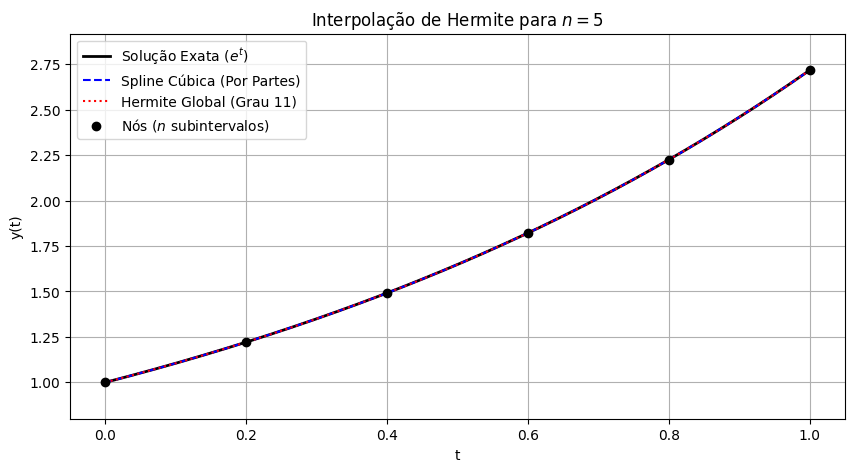

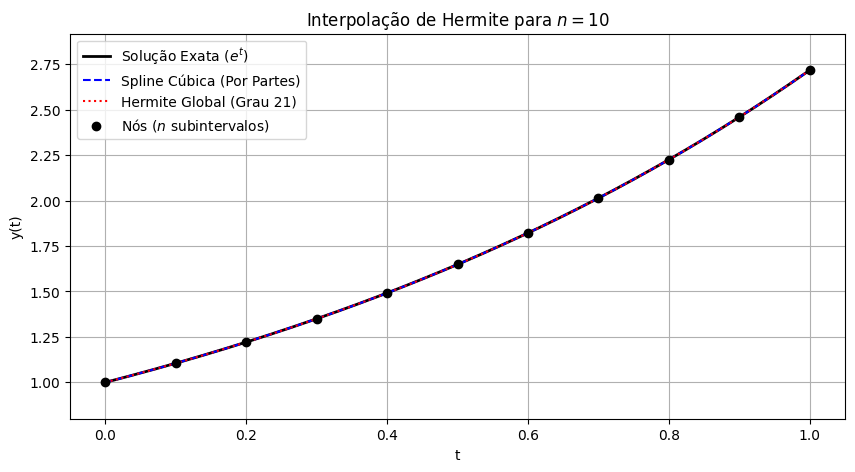

C:\Users\gabri\AppData\Local\Temp\ipykernel_22776\533515637.py:21: UserWarning: 202 degrees provided, degrees higher than about thirty cause problems with numerical instability with 'KroghInterpolator'
  krogh = KroghInterpolator(xi, yi)


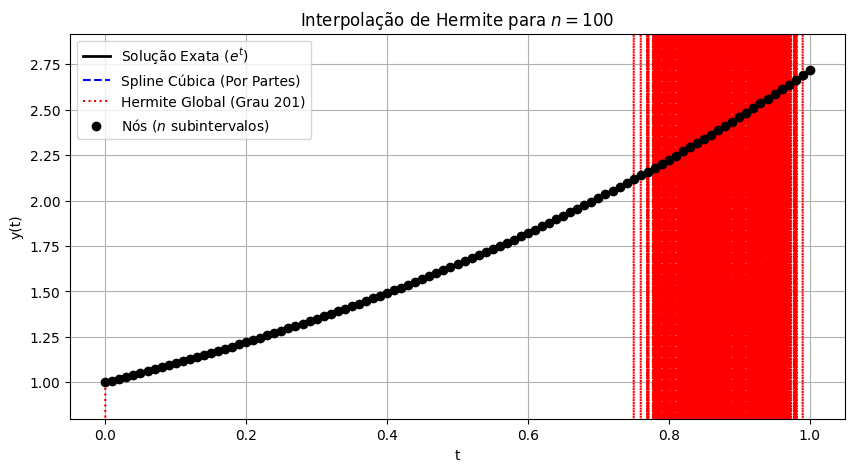

C:\Users\gabri\AppData\Local\Temp\ipykernel_22776\533515637.py:21: UserWarning: 2002 degrees provided, degrees higher than about thirty cause problems with numerical instability with 'KroghInterpolator'
  krogh = KroghInterpolator(xi, yi)
c:\Users\gabri\Documents\PROJETOS\.venv\Lib\site-packages\scipy\interpolate\_polyint.py:349: RuntimeWarning: overflow encountered in divide
  Vk[i+1] = (c[i]-Vk[i])/(xi[i]-xi[k])
c:\Users\gabri\Documents\PROJETOS\.venv\Lib\site-packages\scipy\interpolate\_polyint.py:351: RuntimeWarning: overflow encountered in divide
  Vk[i+1] = (Vk[i+1]-Vk[i])/(xi[i]-xi[k])
c:\Users\gabri\Documents\PROJETOS\.venv\Lib\site-packages\scipy\interpolate\_polyint.py:351: RuntimeWarning: invalid value encountered in subtract
  Vk[i+1] = (Vk[i+1]-Vk[i])/(xi[i]-xi[k])
c:\Users\gabri\Documents\PROJETOS\.venv\Lib\site-packages\scipy\interpolate\_polyint.py:349: RuntimeWarning: invalid value encountered in subtract
  Vk[i+1] = (c[i]-Vk[i])/(xi[i]-xi[k])
c:\Users\gabri\Documents\

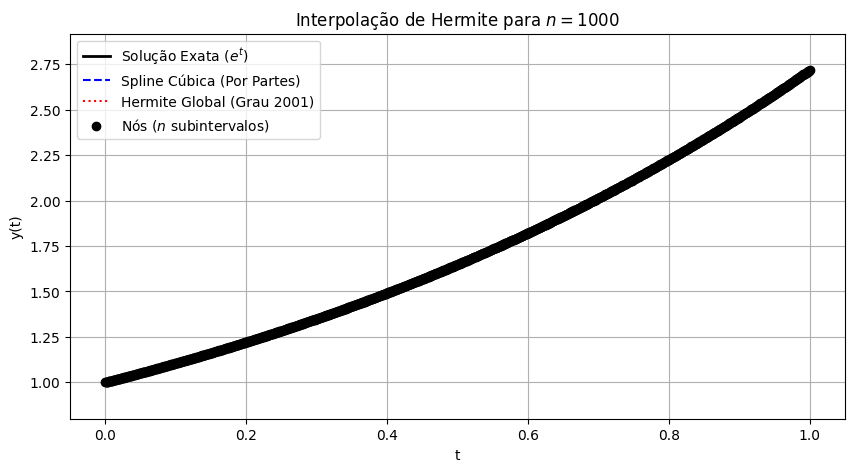

n     , Erro Spline Cúbica       , Erro Hermite Global      
5      | 3.81477e-06               | 9.15552e-16              
10     | 2.38593e-07               | 8.16810e-16              
100    | 2.38650e-11               | 6.49042e+100             
1000   | 2.39556e-15               | nan                      


In [3]:
resolve_edo_hermite([5, 10, 100, 1000])